# 05c: Klasifikácia nelineárnych 2D úloh (MLP)

**Čo tu robíme:** ukázať, že **jedna skrytá vrstva s nelineárnou aktiváciou** dokáže v rovine vytvárať **ohybané rozhodovacie hranice**, zatiaľ čo **čistý lineárny model** (bez skrytej vrstvy) má vždy len **priamu** hranicu. To je kľúčový rozdiel pri úlohách, kde triedy **nie sú lineárne separovateľné**.

**Postup:** najprv dve klasické 2D úlohy — **XOR** (štyri zhluky) a **two‑moons** (dva prepletené oblúky). Pri každej natrénujeme niekoľko sietí s rôznym `hidden_dim` a vykreslíme **oblasť predikcie** (kde model hovorí „trieda 0“ vs „trieda 1“) a **hranicu** tam, kde je pravdepodobnosť triedy 1 rovná 0,5.

Skúšame `hidden_list = [0, 1, 2, 3, 5, 10, 20]`. **`hidden_dim = 0`** = žiadna skrytá vrstva, len **lineárna** mapa z 2 rozmerov na 1 logit (porovnávací **baseline**). Pri väčšom `hidden_dim` sieť môže vstup najprv **nelineárne transformovať** (tu cez `tanh`) a až potom rozhodnúť — preto vie hranica **lámať a ohýbať**.

**Časť B** (nižšie) je iná perspektíva: **1D regresia** na hladkú krivku — tam uvidíš, ako pribúdajúce neuróny umožňujú lepšie sledovať **ohyby** krivky a ako sa to dá spájať s pojmom **inflexný bod**.

In [139]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)
np.random.seed(0)

## 1. Časť A1: XOR (nelineárne separovateľné)

**Idea:** máme **štyri oblaky** v rovine: dva patria triede 0 a dva triede 1, ale **striedajú sa** ako pri logickom XOR (súčasne nemôžu byť obe vstupy „áno“ v tom istom zmysle — tu to vidíš geometricky).

**Prečo je to ťažké pre priamku:** žiadna **jedna priamka** nedokáže oddeliť triedu 0 od triedy 1 tak, aby na každej strane bola len jedna trieda — vždy ostane aspoň jeden zhluk „na zlej strane“. Preto **lineárny klasifikátor** (`hidden_dim = 0`) musí robiť kompromis a hranica vyzerá „hlúpo“.

**Čo očakávať po tréningu:** sieť so **skrytou vrstvou** vie vstup „ohýbať“ v priestore príznakov, takže v poslednej vrstve už **lineárne** oddelí triedy — v pôvodnom `(x₁, x₂)` to vyzerá ako **lomená / krivá** hranica. Rozdiel medzi malým a veľkým počtom neurónov by mal byť na grafe **dobre viditeľný**.

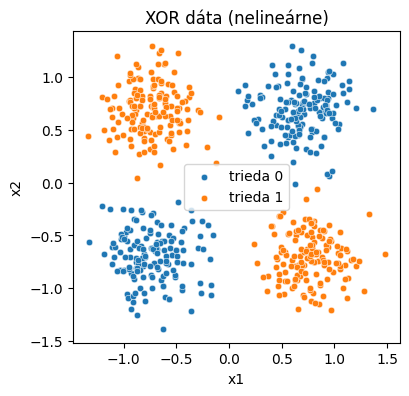

In [140]:
n_per_quadrant = 150
noise = 0.24
# Kompaktnejšie štyri zhluky (bližšie k stredu) — na grafe menej „prázdnoty“ medzi oblakmi
cx = 0.72
q00 = np.random.randn(n_per_quadrant, 2) * noise + np.array([-cx, -cx])
q11 = np.random.randn(n_per_quadrant, 2) * noise + np.array([cx, cx])
q01 = np.random.randn(n_per_quadrant, 2) * noise + np.array([-cx, cx])
q10 = np.random.randn(n_per_quadrant, 2) * noise + np.array([cx, -cx])

X0 = np.vstack([q00, q11])
X1 = np.vstack([q01, q10])

X = np.vstack([X0, X1]).astype(np.float32)
y = np.vstack([np.zeros((X0.shape[0], 1)), np.ones((X1.shape[0], 1))]).astype(np.float32)

# Z-score normalizácia vstupov
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std < 1e-8] = 1.0

X_norm = (X - X_mean) / X_std

X_t = torch.tensor(X_norm)
y_t = torch.tensor(y)

plt.figure(figsize=(4.2, 4.2))
plt.scatter(X0[:, 0], X0[:, 1], c='#1f77b4', s=22, edgecolors='w', linewidths=0.35, label='trieda 0')
plt.scatter(X1[:, 0], X1[:, 1], c='#ff7f0e', s=22, edgecolors='w', linewidths=0.35, label='trieda 1')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('XOR dáta (nelineárne)')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Model: MLP klasifikátor

**Výstup:** jedno číslo — **logit** pre triedu 1. Z neho sa pri vyhodnocovaní spraví **sigmoida** a dostaneš pravdepodobnosť v [0, 1]; prah **0,5** rozdeľuje triedy.

- **`hidden_dim = 0`:** jedna vrstva `Linear(2 → 1)` — žiadna nelinearita. Rozhodovanie je vždy **rovina v priestore príznakov** → v `(x₁, x₂)` **priamka**.

- **`hidden_dim > 0`:** `Linear(2 → H)`, potom **`tanh`** (ohraní hodnoty, umožní „ohyby“), potom `Linear(H → 1)`. Skrytá vrstva má **H** „režimov“; väčšie H znamená **viac voľnosti** v tom, ako zložito vie byť hranica v pôvodných súradniciach.

Prečo práve **jedna** skrytá vrstva: stačí na tieto ukážky a dobre ilustruje, že **kapacita** (počet neurónov) riadi zložitosť hranice.

In [141]:
class MLP2D(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        if hidden_dim == 0:
            # Lineárny klasifikátor: 2 → 1 (žiadna skrytá vrstva)
            self.fc_out = nn.Linear(2, 1)
        else:
            self.fc1 = nn.Linear(2, hidden_dim)
            self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.hidden_dim == 0:
            return self.fc_out(x)
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)

## 3. Tréning

**Strata:** `BCEWithLogitsLoss` — binárna entropia priamo z logitov (numericky stabilnejšie než ručne sigmoid + log). **Optimalizátor:** Adam (prispôsobivé kroky). **Batch:** všetky tréningové body naraz (**full-batch**) — pri takýchto malých dátach je to jednoduché a opakovateľné.

**Normalizácia vstupov** (z-score) je v dátových bunkách: sieť dostáva čísla približne v podobnej škále, čo uľahčuje učenie.

**`train_mlp(X_t, y_t, …)`** berie tenzory **explicitne**, aby pri behu notebooku nevznikla chyba typu „natrénované na XOR, ale kreslím two-moons“ len preto, že sa prepísali globálne premenné.

In [142]:
def train_mlp(X_t, y_t, hidden_dim: int, num_epochs: int = 1000, lr: float = 1e-2):
    """Tréning na zadaných tenzoroch (nie globálnych premenných — aby XOR a two-moons neboli zmiešané)."""
    model = MLP2D(hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    loss_hist = []
    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(X_t)
        loss = criterion(logits, y_t)
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

    return model, loss_hist


@torch.no_grad()
def eval_train_accuracy_pct(model, X_t, y_t):
    """Presnosť na tréningových bodoch: podiel správne zaradených (práh 0,5 na sigmoid)."""
    model.eval()
    pred = (torch.sigmoid(model(X_t)) >= 0.5).float()
    return float((pred == y_t).float().mean().item() * 100.0)


def plot_decision_boundaries(
    models_dict, hidden_list, X0, X1, X, X_mean, X_std, pad=0.12, grid_n=100, acc_dict=None
):
    """Jednoduchá vizualizácia: len dve oblasti (predikcia <0.5 / >0.5), čierna hranica, body — bez „mrakového“ contourf.
    acc_dict: voliteľné {hidden_dim: presnosť v %} pre titulok subplotu."""
    x1_min, x1_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    x2_min, x2_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, grid_n),
        np.linspace(x2_min, x2_max, grid_n),
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()].astype(np.float32)
    grid_norm = (grid - X_mean) / X_std
    grid_t = torch.tensor(grid_norm)

    ncols = 2
    nrows = int(np.ceil(len(hidden_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(9, 2.4 * nrows), squeeze=False)

    for idx, h in enumerate(hidden_list):
        ax = axes.flat[idx]
        with torch.no_grad():
            logits = models_dict[h](grid_t).reshape(xx1.shape)
            probs = torch.sigmoid(logits).numpy()
        ax.contourf(xx1, xx2, probs, levels=[0, 0.5, 1.0], colors=['#a8c8e8', '#f5cba7'], alpha=0.9)
        ax.contour(xx1, xx2, probs, levels=[0.5], colors='k', linewidths=1.4)
        ax.scatter(X0[:, 0], X0[:, 1], c='#1f77b4', s=22, edgecolors='w', linewidths=0.35, zorder=3)
        ax.scatter(X1[:, 0], X1[:, 1], c='#ff7f0e', s=22, edgecolors='w', linewidths=0.35, zorder=3)
        if acc_dict is not None and h in acc_dict:
            ax.set_title(f'hidden_dim = {h}  ({acc_dict[h]:.1f} % tréning)')
        else:
            ax.set_title(f'hidden_dim = {h}')
        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(x2_min, x2_max)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)

    for j in range(len(hidden_list), nrows * ncols):
        axes.flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 2. Tréning pre XOR

Pre každé `hidden_dim` z `hidden_list = [0, 1, 2, 3, 5, 10, 20]` natrénujeme **samostatný** model od náhodnej inicializácie a uložíme ho do slovníka `models`, históriu straty do `losses`. Rovnaký počet epoch a krokového learning rate dáva **porovnateľné** podmienky — rozdiel je len v šírke skrytej vrstvy (a pri 0 v jej absencii).

In [143]:
hidden_list = [0, 1, 2, 3, 5, 10, 20]
models = {}
losses = {}

for h in hidden_list:
    print(f'Trénujem XOR MLP s hidden_dim = {h} ...')
    model_h, loss_hist_h = train_mlp(X_t, y_t, hidden_dim=h, num_epochs=1500, lr=1e-2)
    models[h] = model_h
    losses[h] = loss_hist_h

print('Tréning XOR hotový.')

Trénujem XOR MLP s hidden_dim = 0 ...
Trénujem XOR MLP s hidden_dim = 1 ...
Trénujem XOR MLP s hidden_dim = 2 ...
Trénujem XOR MLP s hidden_dim = 3 ...
Trénujem XOR MLP s hidden_dim = 5 ...
Trénujem XOR MLP s hidden_dim = 10 ...
Trénujem XOR MLP s hidden_dim = 20 ...
Tréning XOR hotový.


## 3. Decision boundary pre XOR

**Ako čítať obrázky:** pozadie je rozdelené na dve farby podľa toho, či model na danej pozícii v rovine dáva triede 1 pravdepodobnosť **nad alebo pod 0,5**. **Čierna čiara** je množina bodov s presne **p = 0,5** — typická **decision boundary**.

Pri **`hidden_dim = 0`** musí byť táto hranica **priamka** — na XOR je to zvyčajne **zlé riešenie** (veľa bodov zle klasifikovaných). Pri dostatočne veľkom `hidden_dim` by hranica mala **obísť** zhluky tak, aby sa farby rozumne zhodovali s farbami bodov.

Štýl je zámerne **jednoduchý** (žiadne preplnené „mraky“ kontúr), aby bolo vidno hlavne **tvar** hranice.

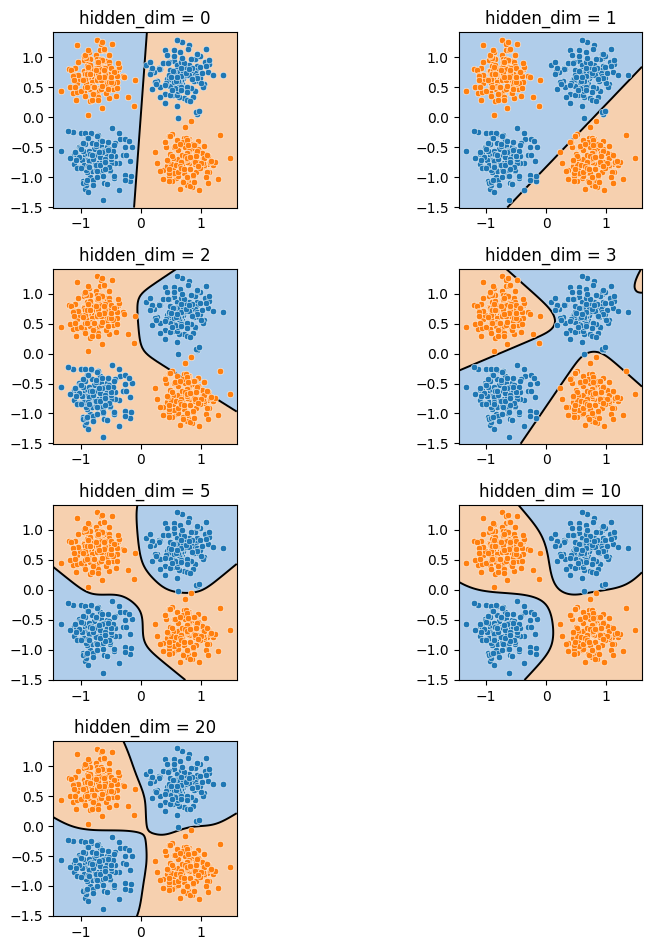

In [144]:
plot_decision_boundaries(models, hidden_list, X0, X1, X, X_mean, X_std)

## 4. Časť A2: Two‑moons (nelineárne separovateľné)

**Geometria:** dva **oblúky** (horný a dolný „mesiac“), ktoré sa v rovine **prepletajú** — ako v klasickej `make_moons` úlohe. Triedy sú **nelineárne separovateľné**: žiadna jedna priamka ich nedokáže dokonale oddeliť.

**Šum:** body sú okolo oblúkov posunuté náhodne (s **väčším rozptylom**), aby sa zhluky **prekrývali** — v praxi to znamená, že ani silná sieť nemusí mať na tréningu **100 %**; presnosť v titulkoch ukazuje, **ako veľmi** sa model dokázal prispôsobiť dátam.

**Prečo to dáva zmysel:** ak by boli body príliš „čisté“, stačila by jednoduchá hranica a rozdiel medzi `hidden_dim = 3` a `15` by nebol vidieť. Pri prekryve je **ohýbaná** hranica naozaj potrebná.

V grafe opäť: **dve farby** = predikcia, **čierna čiara** = p = 0,5. V titulkoch pri two‑moons je ešte **úspešnosť v %** na tréningových bodoch (po prahu 0,5).

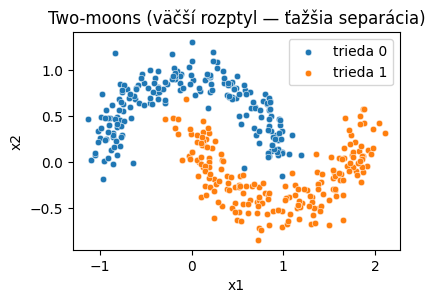

In [145]:
# Two-moons — geometria ako v sklearn.datasets.make_moons (bez importu sklearn)
# Vyšší rozptyl: väčší šum + širší orez → viac prekryvu medzi triedami (ťažšia úloha ako pri noise=0.07)
n_samples = 400
noise_moon = 0.13
noise_clip = 4.0 * noise_moon  # širší než 2.5σ — väčšia disperzia, stále bez extrémnych „výstrelov“

n_half = n_samples // 2
angles = np.linspace(0, np.pi, n_half)

# mierne zúžená škála → oblúky bližšie, viac zmätoku v strede
r = 0.94
x_m1 = r * np.cos(angles)
y_m1 = r * np.sin(angles)
x_m2 = r * (1.0 - np.cos(angles))
y_m2 = r * (1.0 - np.sin(angles)) - 0.5

X0 = np.stack([x_m1, y_m1], axis=1)
X1 = np.stack([x_m2, y_m2], axis=1)

rng = np.random.default_rng(1)
for arr in (X0, X1):
    d = rng.normal(0.0, noise_moon, size=arr.shape).astype(np.float64)
    d = np.clip(d, -noise_clip, noise_clip)
    arr += d

X = np.vstack([X0, X1]).astype(np.float32)
y = np.vstack([np.zeros((n_half, 1)), np.ones((n_half, 1))]).astype(np.float32)

# Z-score normalizácia vstupov
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std < 1e-8] = 1.0

X_norm = (X - X_mean) / X_std

X_t = torch.tensor(X_norm)
y_t = torch.tensor(y)

plt.figure(figsize=(4.2, 4.2))
plt.scatter(X0[:, 0], X0[:, 1], c='#1f77b4', s=22, edgecolors='w', linewidths=0.35, label='trieda 0')
plt.scatter(X1[:, 0], X1[:, 1], c='#ff7f0e', s=22, edgecolors='w', linewidths=0.35, label='trieda 1')
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Two-moons (väčší rozptyl — ťažšia separácia)')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Tréning pre two‑moons

Použijeme **rovnaký** `hidden_list` ako pri XOR, ale **iné dáta** (`X_t`, `y_t` z predcházejúcej bunky). Každý model sa učí **iba** na two‑moons — výsledky s XOR **neporovnávaj** číselne, len myšlienku (nelineárna hranica vs lineárna).

Po tréningu uvidíš v konzole **presnosť** pre každé `hidden_dim`; tieto hodnoty sa potom prepíšu aj do titulkov grafov.

In [146]:
models_moons = {}
losses_moons = {}
acc_moons = {}

for h in hidden_list:
    print(f'Trénujem two‑moons MLP s hidden_dim = {h} ...')
    model_h, loss_hist_h = train_mlp(X_t, y_t, hidden_dim=h, num_epochs=1500, lr=5e-3)
    models_moons[h] = model_h
    losses_moons[h] = loss_hist_h
    acc_moons[h] = eval_train_accuracy_pct(model_h, X_t, y_t)
    print(f'  → presnosť na tréningu: {acc_moons[h]:.1f} %')

print('Tréning two‑moons hotový.')

Trénujem two‑moons MLP s hidden_dim = 0 ...
  → presnosť na tréningu: 87.0 %
Trénujem two‑moons MLP s hidden_dim = 1 ...
  → presnosť na tréningu: 87.3 %
Trénujem two‑moons MLP s hidden_dim = 2 ...
  → presnosť na tréningu: 87.7 %
Trénujem two‑moons MLP s hidden_dim = 3 ...
  → presnosť na tréningu: 99.3 %
Trénujem two‑moons MLP s hidden_dim = 5 ...
  → presnosť na tréningu: 98.8 %
Trénujem two‑moons MLP s hidden_dim = 10 ...
  → presnosť na tréningu: 99.5 %
Trénujem two‑moons MLP s hidden_dim = 20 ...
  → presnosť na tréningu: 99.8 %
Tréning two‑moons hotový.


## 6. Decision boundary pre two‑moons

**Čo znamená číslo v zátvorkách:** podiel tréningových bodov, kde **predikovaná trieda** (po sigmoide a prahu 0,5) sedí so **skutočnou** značkou. Je to **tréningová** presnosť — na tomto malom datasete ju používame ako jednoduchú spätnú väzbu, nie ako finálnu metriku na nové dáta.

**Čo očakávať:** pri **`hidden_dim = 0`** je hranica stále **priamka** — na prepletených mesiacoch to často znamená **veľa chýb** (body „v zlej polovici“). Pri viacerých neurónoch môže hranica **obeť oblúky**; presnosť môže rásť, ale pri silnom šume nemusí byť 100 % — a to je v poriadku, lebo sa úloha **zámerne** snaží byť trochu „špinavá“.

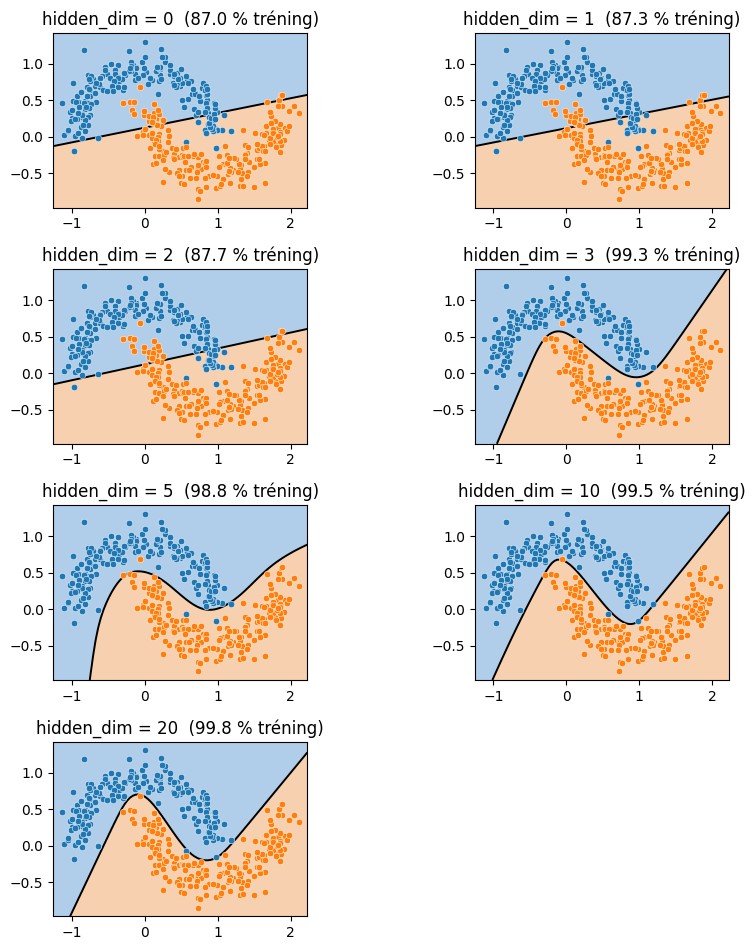

In [147]:
plot_decision_boundaries(
    models_moons, hidden_list, X0, X1, X, X_mean, X_std, acc_dict=acc_moons
)

## Časť B: 1D aproximácia sinusovej krivky (inflexné body)

Tu sa pozeráme na **regresiu**: vstup je jedno číslo `x`, výstup je `y` na hladkej krivke. V 1D je pojem **inflexný bod** geometricky jasný: miesto, kde krivka **mení zakrivenie** (z „konkávnej“ na „konvexnú“ alebo naopak).

Cieľová funkcia je \(y = \sin(3x) + 0.3x\). Na intervale \([-2, 2]\) má **tri inflexné body** — tam, kde je druhá derivácia nulová (pre čistý \(\sin(3x)\) sú to body, kde \(\sin(3x) = 0\)).

**Prečo to patrí do toho istého notebooku:** v 2D sme riešili **tvar hranice** (koľko „ohybov“ vie sieť spraviť v rovine). V 1D riešime **tvar krivky** — koľko „ohybov“ vie sieť napodobniť pozdĺž osi. Obe intuície hovoria o **kapacite** siete: viac neurónov → zložitejšia aproximácia.

Nižšie sú **šedé zvislé čiary** na teoretických inflexných bodoch a červené krivky — aproximácia MLP pre rôzne šírky skrytej vrstvy.

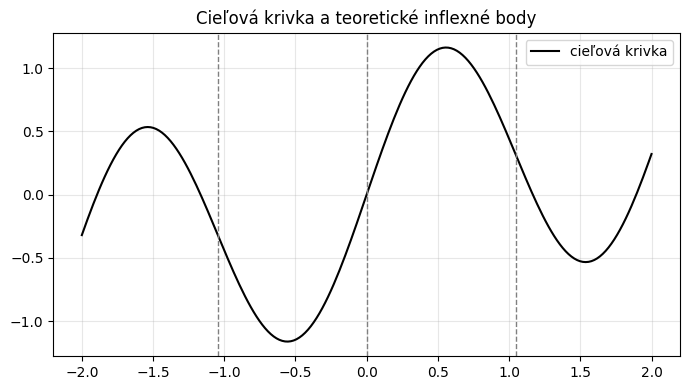

In [148]:
# 1D dáta
x_1d = np.linspace(-2.0, 2.0, 200, dtype=np.float32).reshape(-1, 1)
y_1d = np.sin(3 * x_1d) + 0.3 * x_1d

# z-score pre 1D regresiu
x1_mean, x1_std = float(x_1d.mean()), float(x_1d.std())
y1_mean, y1_std = float(y_1d.mean()), float(y_1d.std())
if x1_std < 1e-8:
    x1_std = 1.0
if y1_std < 1e-8:
    y1_std = 1.0
x1_norm = (x_1d - x1_mean) / x1_std
y1_norm = (y_1d - y1_mean) / y1_std

# teoretické inflexné body x = k*pi/3 v rozsahu [-2,2]
xs = []
for k in range(-3, 4):
    xk = k * np.pi / 3
    if -2.0 <= xk <= 2.0:
        xs.append(xk)

plt.figure(figsize=(7, 4))
plt.plot(x_1d, y_1d, 'k', label='cieľová krivka')
for xk in xs:
    plt.axvline(xk, color='gray', linestyle='--', linewidth=1)
plt.title('Cieľová krivka a teoretické inflexné body')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

In [149]:
class MLP1D(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        if hidden_dim == 1:
            nn.init.xavier_uniform_(self.fc1.weight, gain=0.1)
            nn.init.zeros_(self.fc1.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)


def train_mlp_1d(hidden_dim: int, num_epochs: int = 2000, lr: float = 1e-3):
    model = MLP1D(hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    x_t_1d = torch.tensor(x1_norm)
    y_t_1d = torch.tensor(y1_norm)

    loss_hist = []
    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred = model(x_t_1d)
        loss = criterion(pred, y_t_1d)
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

    return model, loss_hist

Trénujem 1D MLP s hidden_dim = 1 ...
Trénujem 1D MLP s hidden_dim = 2 ...
Trénujem 1D MLP s hidden_dim = 3 ...
Trénujem 1D MLP s hidden_dim = 5 ...
Trénujem 1D MLP s hidden_dim = 10 ...
Trénujem 1D MLP s hidden_dim = 20 ...
Trénujem 1D MLP s hidden_dim = 30 ...
Trénujem 1D MLP s hidden_dim = 40 ...


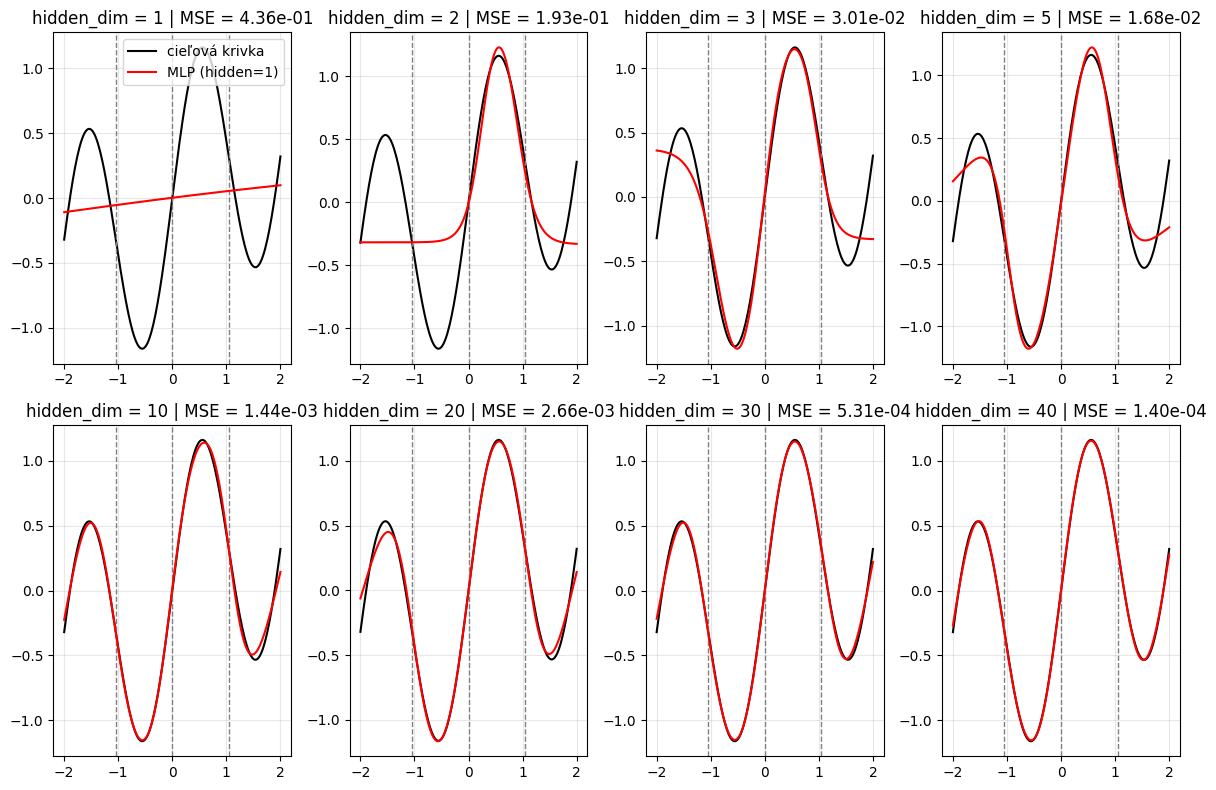

In [152]:
hidden_list_1d = [1, 2, 3, 5, 10, 20, 30, 40]
models_1d = {}

for h in hidden_list_1d:
    print(f'Trénujem 1D MLP s hidden_dim = {h} ...')
    model_h, _ = train_mlp_1d(hidden_dim=h, num_epochs=4500, lr=1e-3)
    models_1d[h] = model_h

# grafy
x_plot_1d = x_1d
x_plot_norm = (x_plot_1d - x1_mean) / x1_std
x_plot_t = torch.tensor(x_plot_norm)

plt.figure(figsize=(12, 8))
for i, h in enumerate(hidden_list_1d, start=1):
    plt.subplot(2, 4, i)
    plt.plot(x_1d, y_1d, 'k', label='cieľová krivka')
    for xk in xs:
        plt.axvline(xk, color='gray', linestyle='--', linewidth=1)
    with torch.no_grad():
        y_pred_norm = models_1d[h](x_plot_t).detach().numpy()
    y_pred = y_pred_norm * y1_std + y1_mean
    mse = float(np.mean((y_pred - y_1d) ** 2))
    plt.plot(x_plot_1d, y_pred, 'r', label=f'MLP (hidden={h})')
    plt.title(f'hidden_dim = {h} | MSE = {mse:.2e}')
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend()

plt.tight_layout()
plt.show()

## 6. Priebeh loss (XOR)

Graf ukazuje, ako počas učenia klesá **binárna cross-entropia** na **XOR** tréningových dátach — pre každé `hidden_dim` jedna krivka. **Logaritmická os y** zvýrazňuje, či strata ešte pomaly klesá, alebo už stagnuje.

**Ako čítať:** nižšia strata znamená lepšie logitové zhody s cieľovými značkami; ak sa krivky krížia, môže to byť náhoda inicializácie alebo rýchlosť učenia — dôležitejší je **koniec** učenia a predovšetkým **tvar hranice** v predchádzajúcom grafe. Tento graf je doplnkový prehľad k XOR časti.

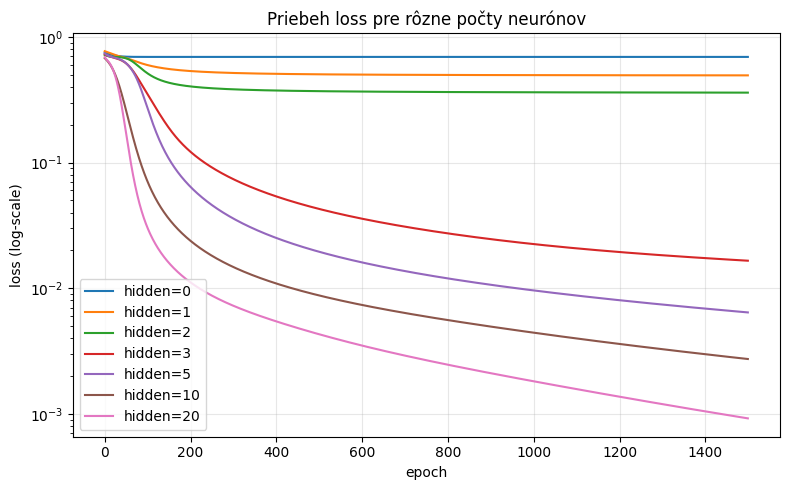

In [153]:
plt.figure(figsize=(8, 5))
for h in hidden_list:
    plt.plot(losses[h], label=f'hidden={h}')
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('loss (log-scale)')
plt.title('Priebeh loss pre rôzne počty neurónov')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

## 7. Zhrnutie

- **Časť A — 2D klasifikácia:** Bez skrytej vrstvy (`hidden_dim = 0`) je rozhodovanie v rovine vždy **jedna polovica roviny oddelená priamkou** (ktorá strana je „trieda 1“). Pri XOR a two‑moons to často nestačí. **Skrytá vrstva s `tanh`** dovolí vstup najprv **nelineárne premeniť**, takže v pôvodných súradniciach môže vyzerať hranica **ohybaná**. Viac neurónov zväčša znamená **väčšiu voľnosť** v tvare tejto hranice (až kým nepreučíme alebo dáta nebudú príliš hlučné).

- **Časť B — 1D regresia:** Vertikálne čiary sú **inflexné body** cieľa; MLP sa snaží prejsť bodmi tak, aby **MSE** bolo malé. Viac neurónov umožňuje presnejšie sledovať **lomenú** krivku — podobne ako v 2D „viac ohybov“ hranice.

**Spoločná myšlienka:** šírka skrytej vrstvy je jednoduchý **„gombík“ na kapacitu** — nie je to jediný ani vždy najlepší parameter v praxi, ale na demonštráciu je prehľadný.